这里虽然是仅打分，但是依旧推荐采用注释modeling的方式

In [1]:
%reset -f
%reload_ext autoreload
%autoreload 2

In [2]:
import os,sys
current_path = os.getcwd()
sys.path.append("/home/zhuchen/poc/scorecard") 
sys.path.append("/home/zhuchen/poc/02-xyf2/config") 

In [3]:
name = current_path.split('/')[-1].split('_')
data = name[0]
cust = name[1]

In [4]:
print(name)

['deltaV1', 'all']


In [5]:
FILE_PATH = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/file/'
DATA_PATH = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/data/'
TMP_PATH  = f'/home/zhuchen/poc/02-xyf2/{data}_{cust}/tmp/'
DATA_OR_PATH = '/home/zhuchen/poc/02-xyf2/data_or/'

In [6]:
import pandas as pd 
import numpy as np  
import math  
import matplotlib.pyplot as plt
import copy
import seaborn as sns
from pylab import mpl
import temp_config 

isExists=os.path.exists(FILE_PATH)
if not isExists:
    os.makedirs(FILE_PATH) 
    
isExists=os.path.exists(DATA_PATH)
if not isExists:
    os.makedirs(DATA_PATH) 

import warnings
warnings.filterwarnings("ignore")

In [7]:
#config cell
epoch = temp_config.epoch
print("epoch \n",epoch)

epoch 
 3000


In [8]:
# optuna_index = temp_config.optuna_index
optuna_index = 1
print("optuna_index \n",optuna_index)

optuna_index 
 1


In [9]:
import gc
gc.collect()

0

In [10]:
# data_all = pd.read_pickle(DATA_PATH + 'data_end.pkl')
data_all = pd.read_csv(DATA_PATH + 'data_ft_2.csv')

In [11]:
ex_lst = ['mobile','backPointTime','qudao3_act','label',
 'weight',
 'target',
 'month_time',
 'day_time',
 'week_time',]
ft_lst = [i for i in data_all.columns if i not in ex_lst]
len(ft_lst)

print('num_feature: ', len(ft_lst))
print('data_shape: ', data_all.shape)

num_feature:  57
data_shape:  (1277742, 66)


In [12]:
best_flag = pd.read_csv(FILE_PATH + 'best_flag.csv')['best_flag'].tolist()[0]

In [13]:
from DataPreprocessing.Datasets.Split import by_stratify
data_all, res = by_stratify(data_all, 0.3, best_flag, date='backPointTime', dep='label')

         count  bad_rate      bad    time_min    time_max
all    1277742  0.046695  59664.0  2024-07-01  2025-06-22
train   803775  0.046010  36982.0  2024-07-01  2025-05-10
valid   344476  0.046009  15849.0  2024-07-01  2025-05-10
oot     129491  0.052768   6833.0  2025-05-11  2025-06-22
ratio_bad_good:  0.04822944393076097
train    803775
valid    344476
oot      129491
Name: target, dtype: int64


In [14]:
res

,count,bad_rate,bad,time_min,time_max
all,1277742,0.046695,59664.0,2024-07-01,2025-06-22
train,803775,0.046010,36982.0,2024-07-01,2025-05-10
valid,344476,0.046009,15849.0,2024-07-01,2025-05-10
oot,129491,0.052768,6833.0,2025-05-11,2025-06-22


## 模型调参

In [15]:
# keep_lst = iv_keep
# data_end = data_all[keep_lst + ex_lst].copy()
# data_end.to_pickle(DATA_PATH + 'data_end_before_modeling.pkl')
# pd.DataFrame({'var_names':keep_lst}).to_csv('keep_lst.csv', index=False)
# len(keep_lst)

In [16]:
keep_lst = ft_lst
data_end = data_all

In [17]:
import gc
gc.collect()

0

In [18]:
ress = pd.read_excel(FILE_PATH + 'optuna.xlsx')

In [19]:
th = 0.05
th1 = 0.1
if 'oot_ks' in ress.columns:
    res = ress[ress['valid_ks'] > th][['train_ks', 'valid_ks', 'oot_ks']]
    res = res[res['train_ks'] > th]
    res = res[res['oot_ks'] > th]
    res['delta'] = res['train_ks'] - res['oot_ks']
    res['delta1'] = res['valid_ks'] - res['oot_ks']
    res['delta2'] = res['valid_ks'] - res['train_ks']
    res = res[abs(res['delta']) < th1]
    res = res[abs(res['delta1']) < th1]
    res = res[abs(res['delta2']) < th1]
    res.sort_values(by='oot_ks', ascending=False, inplace=True)
else:
    res = ress[ress['valid_ks'] > th][['train_ks', 'valid_ks']]
    res = res[res['train_ks'] > th]
    res['delta2'] = res['valid_ks'] - res['train_ks']
    res = res[abs(res['delta2']) < 0.03]
    res.sort_values(by='valid_ks', ascending=False, inplace=True)
res = res.copy()
res

,train_ks,valid_ks,oot_ks,delta,delta1,delta2
3,0.094707,0.092572,0.058145,0.036562,0.034427,-0.002135
329,0.089419,0.089039,0.057637,0.031782,0.031401,-0.000380
236,0.090039,0.090804,0.057389,0.032650,0.033415,0.000766
1341,0.088421,0.089327,0.057239,0.031181,0.032087,0.000906
1871,0.089907,0.090667,0.057212,0.032695,0.033455,0.000760
...,...,...,...,...,...,...
66,0.081377,0.085607,0.050149,0.031227,0.035457,0.004230
2789,0.079300,0.083922,0.050109,0.029191,0.033812,0.004622
483,0.082307,0.086044,0.050060,0.032247,0.035984,0.003737
2208,0.079389,0.083634,0.050054,0.029335,0.033580,0.004245


In [20]:
res.to_csv(DATA_PATH + 'res.csv')

In [21]:
from ScoreCard.evaluation import ScorecardEvaluation
se = ScorecardEvaluation('信贷')

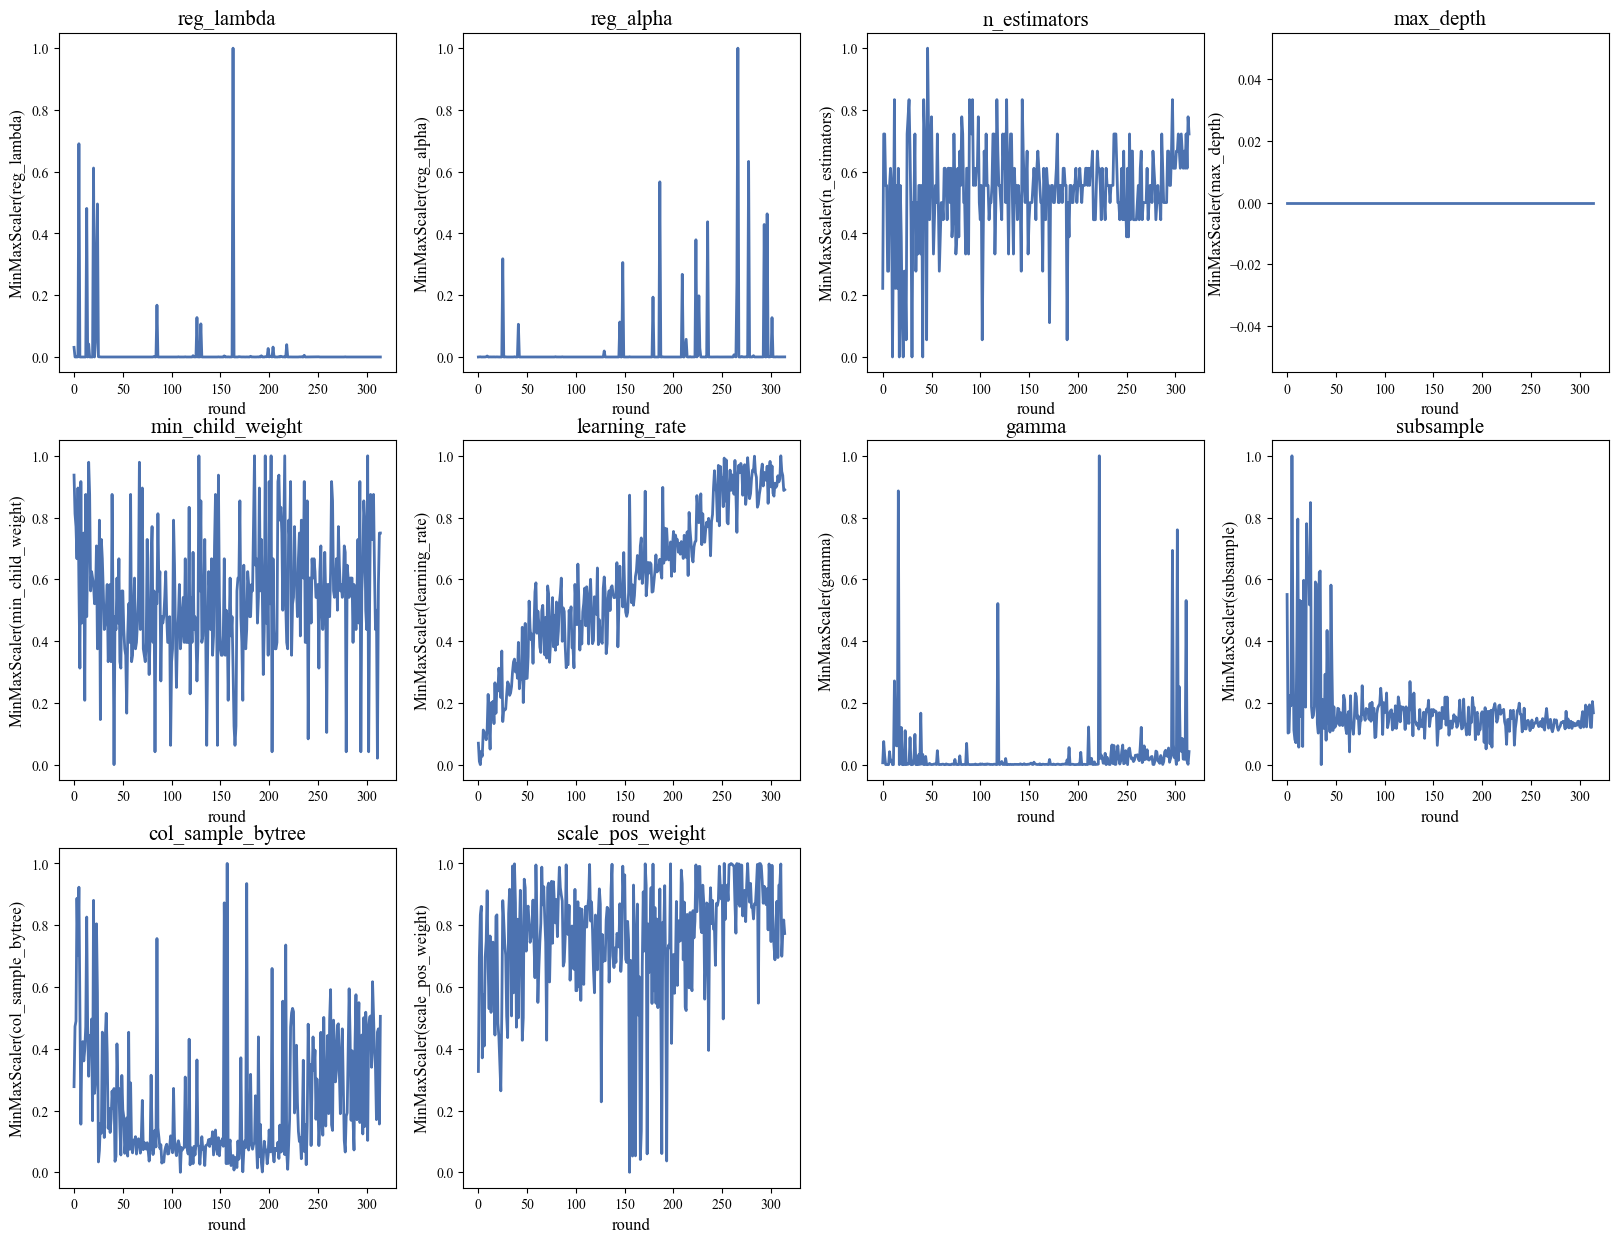

In [22]:
se.parameter_fluctuation_curve(FILE_PATH + 'optuna.xlsx',0.01,'xgb')

### 最终模型

In [23]:
# data_end = pd.read_pickle(DATA_PATH + 'data_end_before_modeling.pkl')

In [24]:
params = eval(ress.iloc[res.index[optuna_index]]['model_param'])
params

{'verbosity': 0,
 'booster': 'gbtree',
 'reg_lambda': 0.015472002714610763,
 'reg_alpha': 3.8066173031276675e-07,
 'n_estimators': 40,
 'max_depth': 1,
 'min_child_weight': 4,
 'learning_rate': 0.2992874018227153,
 'col_sample_bytree': 0.14425640403917528,
 'scale_pos_weight': 32.025407044219826,
 'gamma': 0.0005779872241334999,
 'subsample': 0.5493823538064566}

In [25]:
from Model.train import show
import xgboost as xgb
nan = np.nan

print('num_features: ', len(keep_lst))
model = xgb.XGBClassifier(**params)

model.fit(data_end[data_end['target'] == 'train'][keep_lst], 
          data_end[data_end['target'] == 'train']['label'], 
          sample_weight=data_end[data_end['target'] == 'train']['weight'])

import joblib
joblib.dump(model, 'model.model')
model = joblib.load('model.model')

num_features:  57


  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.562401   0.050482  0.820507  0.089419  0.202558  0.569979   
0    valid  0.562022   0.050854  0.806108  0.089039  0.203035  0.576013   
0      oot  0.534672   0.055024  0.901507  0.057637  0.221132  0.532167   

      ratio   count  
0  0.747835  803775  
0  0.729308  344476  
0  0.864547  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.562401  0.089419   0.050482  0.820507  0.202558  0.569979   
0    valid  0.562022  0.089039   0.050854  0.806108  0.203035  0.576013   
0      oot  0.534672  0.057637   0.055024  0.901507  0.221132  0.532167   

      ratio   count  
0  0.747835  803775  
0  0.729308  344476  
0  0.864547  129491  


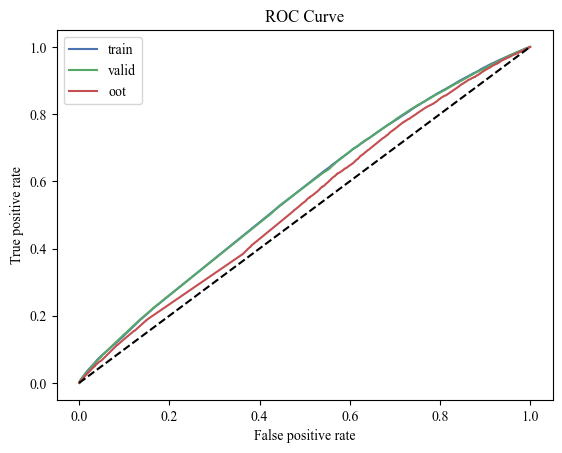

In [26]:
res_data = se.eval_dataset(data_end, model, keep_lst, col_name='target')

  datasets       auc  precision    recall        ks        f2        th  \
0  2024-07  0.552126   0.035740  0.640038  0.081577  0.146072  0.602043   
0  2024-08  0.553962   0.040001  0.807197  0.077893  0.166920  0.566803   
0  2024-09  0.558685   0.045448  0.768792  0.087793  0.183783  0.582657   
0  2024-10  0.570083   0.050086  0.775135  0.098513  0.198996  0.584214   
0  2024-11  0.573190   0.053528  0.733811  0.110280  0.207186  0.592979   
0  2024-12  0.559133   0.050542  0.822133  0.084839  0.202831  0.570196   
0  2025-01  0.567947   0.053559  0.754814  0.100024  0.208591  0.592387   
0  2025-02  0.567688   0.058273  0.856020  0.097150  0.229008  0.567184   
0  2025-03  0.564064   0.062628  0.802617  0.090474  0.238651  0.583161   
0  2025-04  0.551840   0.058370  0.883868  0.076405  0.230864  0.551941   
0  2025-05  0.535572   0.055195  0.900828  0.051505  0.221650  0.538755   
0  2025-06  0.526624   0.055332  0.934110  0.052861  0.223665  0.516557   

      ratio   count  
0 

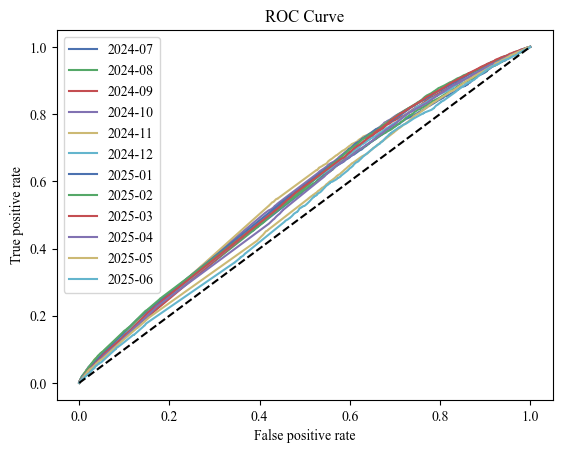

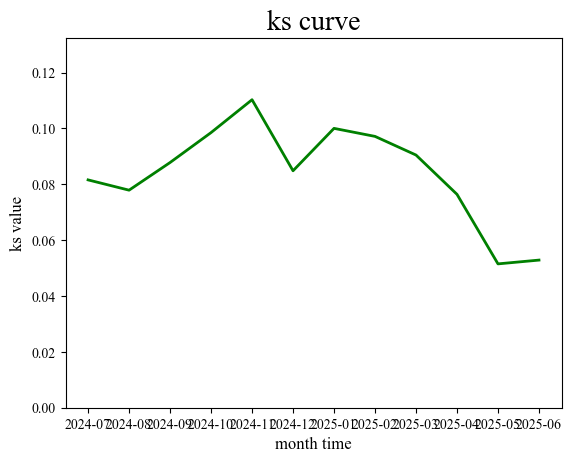

In [27]:
res_month = se.eval_month(data_end, model, keep_lst, col_name='month_time')

In [28]:
importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_})
importance.sort_values(by='importance', ascending=False)

,var_names,importance
0,TZ_0265_m15,0.314584
32,TZ_0277_m24,0.146562
41,TZ_0265_m12,0.090240
25,TZ_0099_m6,0.087337
19,TZ_0096_m3,0.053729
50,TZ_0279_m24,0.047617
27,TZ_1574_m12,0.045761
17,TZ_0099_m3,0.033613
18,TZ_0097_m3,0.028570
39,TZ_0265_m6,0.027498


In [29]:
importance.sort_values(by='importance', ascending=False).head()

,var_names,importance
0,TZ_0265_m15,0.314584
32,TZ_0277_m24,0.146562
41,TZ_0265_m12,0.090240
25,TZ_0099_m6,0.087337
19,TZ_0096_m3,0.053729


In [30]:
end_keep = list(importance[importance['importance']>0]['var_names'])
len(end_keep)

17

In [31]:
keep_lst = end_keep

In [32]:
from Model.train import show
import xgboost as xgb
nan = np.nan

print('num_features: ', len(keep_lst))
model = xgb.XGBClassifier(**params)

model.fit(data_end[data_end['target'] == 'train'][keep_lst], 
          data_end[data_end['target'] == 'train']['label'], 
          sample_weight=data_end[data_end['target'] == 'train']['weight'])

import joblib
joblib.dump(model, 'model.model')
model = joblib.load('model.model')

num_features:  17


  datasets       auc  precision    recall        ks        f2        th  \
0    train  0.562401   0.050482  0.820507  0.089419  0.202558  0.569979   
0    valid  0.562022   0.050854  0.806108  0.089039  0.203035  0.576013   
0      oot  0.534672   0.055024  0.901507  0.057637  0.221132  0.532167   

      ratio   count  
0  0.747835  803775  
0  0.729308  344476  
0  0.864547  129491  
  datasets       auc        ks  precision    recall        f2        th  \
0    train  0.562401  0.089419   0.050482  0.820507  0.202558  0.569979   
0    valid  0.562022  0.089039   0.050854  0.806108  0.203035  0.576013   
0      oot  0.534672  0.057637   0.055024  0.901507  0.221132  0.532167   

      ratio   count  
0  0.747835  803775  
0  0.729308  344476  
0  0.864547  129491  


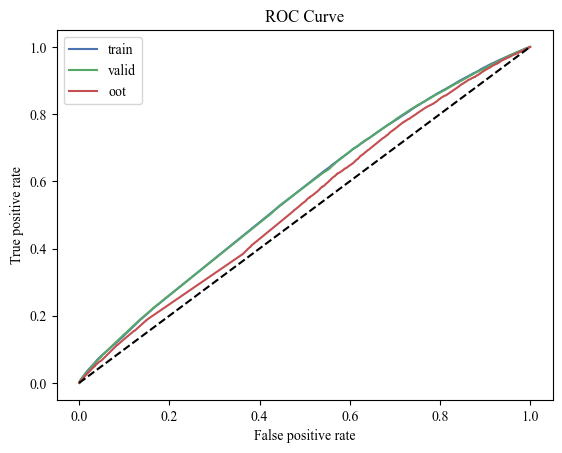

In [33]:
res_data = se.eval_dataset(data_end, model, keep_lst, col_name='target')

  datasets       auc  precision    recall        ks        f2        th  \
0  2024-07  0.552126   0.035740  0.640038  0.081577  0.146072  0.602043   
0  2024-08  0.553962   0.040001  0.807197  0.077893  0.166920  0.566803   
0  2024-09  0.558685   0.045448  0.768792  0.087793  0.183783  0.582657   
0  2024-10  0.570083   0.050086  0.775135  0.098513  0.198996  0.584214   
0  2024-11  0.573190   0.053528  0.733811  0.110280  0.207186  0.592979   
0  2024-12  0.559133   0.050542  0.822133  0.084839  0.202831  0.570196   
0  2025-01  0.567947   0.053559  0.754814  0.100024  0.208591  0.592387   
0  2025-02  0.567688   0.058273  0.856020  0.097150  0.229008  0.567184   
0  2025-03  0.564064   0.062628  0.802617  0.090474  0.238651  0.583161   
0  2025-04  0.551840   0.058370  0.883868  0.076405  0.230864  0.551941   
0  2025-05  0.535572   0.055195  0.900828  0.051505  0.221650  0.538755   
0  2025-06  0.526624   0.055332  0.934110  0.052861  0.223665  0.516557   

      ratio   count  
0 

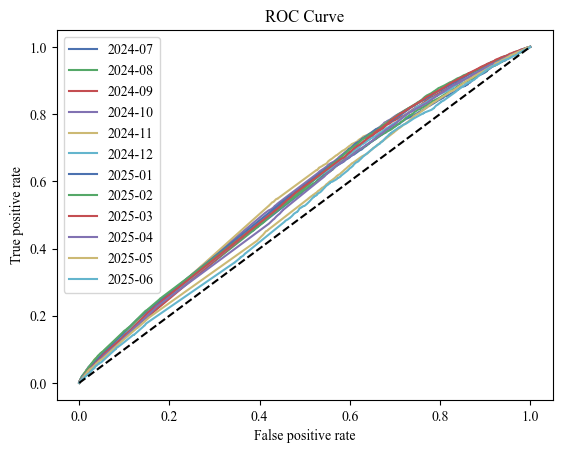

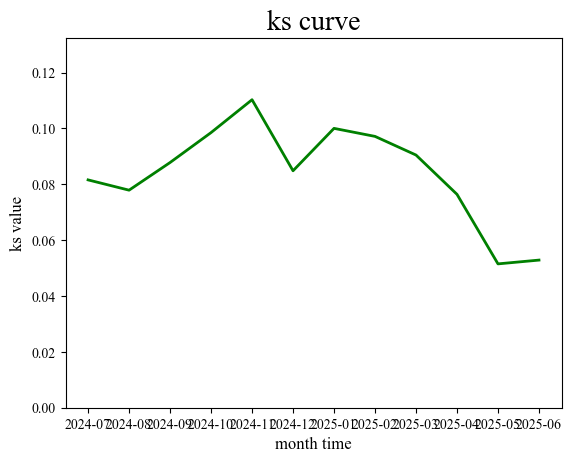

In [34]:
res_month = se.eval_month(data_end, model, keep_lst, col_name='month_time')

In [35]:
importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_})
importance.sort_values(by='importance', ascending=False)

,var_names,importance
0,TZ_0265_m15,0.314584
12,TZ_0277_m24,0.146562
14,TZ_0265_m12,0.090240
10,TZ_0099_m6,0.087337
8,TZ_0096_m3,0.053729
16,TZ_0279_m24,0.047617
11,TZ_1574_m12,0.045761
6,TZ_0099_m3,0.033613
7,TZ_0097_m3,0.028570
13,TZ_0265_m6,0.027498


In [36]:
importance.sort_values(by='importance', ascending=False).head()

,var_names,importance
0,TZ_0265_m15,0.314584
12,TZ_0277_m24,0.146562
14,TZ_0265_m12,0.090240
10,TZ_0099_m6,0.087337
8,TZ_0096_m3,0.053729


### 分数评估

In [37]:
data_end.head()

,TZ_0265_m15,TZ_0282_m24,TZ_0089_m24,TZ_0280_m24,TZ_0091_m24,TZ_0088_m24,TZ_0281_m18,TZ_0265_m18,TZ_0282_m18,TZ_0280_m15,...,TZ_0455_m3,mobile,backPointTime,qudao3_act,label,weight,target,month_time,day_time,week_time
0,0.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,...,8.0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,1,train,2024-08,2024-08-11,32
1,0.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,...,8.0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,1,valid,2024-08,2024-08-11,32
2,0.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,...,0.0,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.0,1,valid,2025-02,2025-02-21,8
3,5.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,5.0,-1.0,-1.0,...,3.0,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.0,1,oot,2025-06,2025-06-09,24
4,1.0,-1.0,0.0,-1.0,0.0,0.0,-1.0,1.0,-1.0,-1.0,...,-1.0,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.0,1,valid,2025-04,2025-04-28,18


In [38]:
from new_tools import auto_score
# 开始分数转换
scorer = auto_score.ScoreCalculator(max_score=900, min_score=300)  # 实例化分数计算器
data_end['proba'] =  model.predict_proba(data_end[keep_lst])[:, 1]
scores, min_score, max_score, final_p, final_q, final_pdo = scorer.automatic_scoring(data_end['proba'])
data_end['score'] = scores

pdo_df = pd.DataFrame({'Min Score': min_score,
                        'Max Score': max_score,
                        'P': final_p,
                        'Q': final_q,
                        'PDO': final_pdo},index=[0])
# 打印结果
print(f"Min Score: {min_score}, Max Score: {max_score}, P: {final_p}, Q: {final_q}, PDO: {final_pdo}")

def card_score(pred, P=final_p, Q=final_q, PDO=final_pdo, good_weight=1):
    '''
    根据概率1返回卡评分
    pred:概率(array或scalar); Q:设定的Odds比率; P:比率Q时的分数
    PDO:比率为2Q时分值增加量; good_weight:好客户抽样比例
    '''
    Odds = (1-pred)*good_weight/pred
    B = -PDO/np.log(2)
    A = P + B*np.log(Q)
    score = A - B*np.log(Odds)
    # score[score<350] = 350
    # score[score>850] = 1000
    return score.astype(int)
	
data_end['score'] = card_score(data_end['proba'])

print(data_end['proba'].min(),data_end['proba'].max())
print(data_end['score'].min(),data_end['score'].max())
data_end[['score','proba']].head()

Min Score: 336, Max Score: 898, P: 1150, Q: 10, PDO: 140
0.25798059 0.8490073
336 898


,score,proba
0,583,0.622792
1,583,0.622792
2,581,0.625168
3,700,0.481265
4,622,0.576269


In [39]:
# data_end.to_pickle(DATA_PATH + 'data_end.pkl')

In [40]:
data_end.to_csv(DATA_PATH + '打分文件.csv')

In [41]:
data_end

,TZ_0265_m15,TZ_0282_m24,TZ_0089_m24,TZ_0280_m24,TZ_0091_m24,TZ_0088_m24,TZ_0281_m18,TZ_0265_m18,TZ_0282_m18,TZ_0280_m15,...,backPointTime,qudao3_act,label,weight,target,month_time,day_time,week_time,proba,score
0,0.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,...,2024-08-11,信息流,0.0,1,train,2024-08,2024-08-11,32,0.622792,583
1,0.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,...,2024-08-11,信息流,0.0,1,valid,2024-08,2024-08-11,32,0.622792,583
2,0.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,0.0,-1.0,-1.0,...,2025-02-21,API,0.0,1,valid,2025-02,2025-02-21,8,0.625168,581
3,5.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,5.0,-1.0,-1.0,...,2025-06-09,API,0.0,1,oot,2025-06,2025-06-09,24,0.481265,700
4,1.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,1.0,-1.0,-1.0,...,2025-04-28,API,0.0,1,valid,2025-04,2025-04-28,18,0.576269,622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277737,4.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,4.0,-1.0,-1.0,...,2024-11-13,APP自然流量,0.0,1,valid,2024-11,2024-11-13,46,0.551777,642
1277738,3.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,3.0,-1.0,-1.0,...,2024-11-15,APP自然流量,0.0,1,valid,2024-11,2024-11-15,46,0.542939,650
1277739,5.0,24.0,1.0,31.0,0.07971,2.0,-1.0,5.0,-1.0,-1.0,...,2024-11-12,APP自然流量,0.0,1,train,2024-11,2024-11-12,46,0.505571,680
1277740,-1.0,-1.0,0.0,-1.0,0.00000,0.0,-1.0,-1.0,-1.0,-1.0,...,2024-11-23,APP自然流量,0.0,1,train,2024-11,2024-11-23,47,0.632387,575


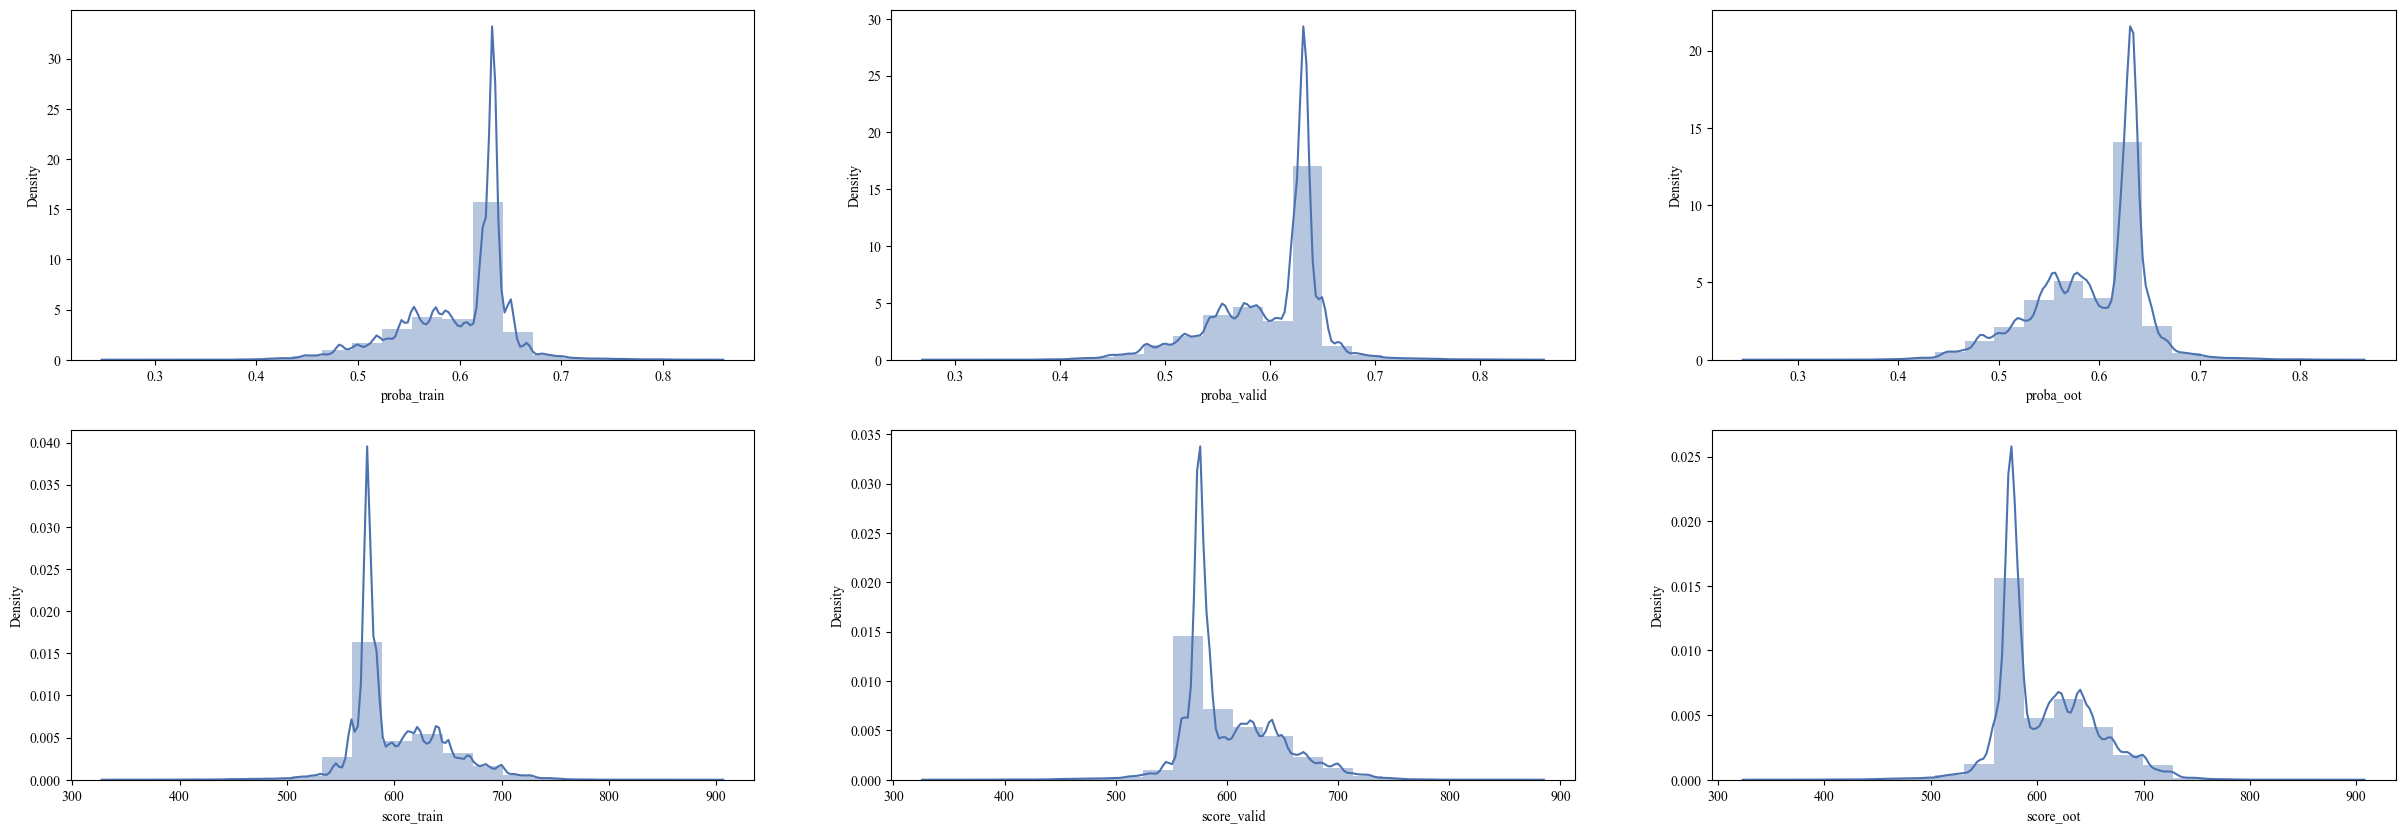

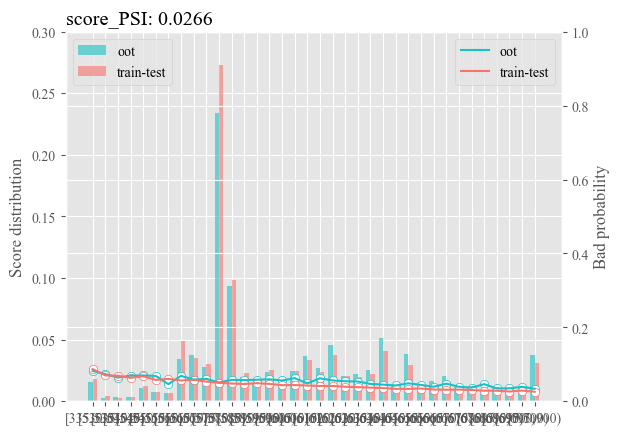

In [42]:
plt.style.use('seaborn-deep')
plt.rcParams['font.sans-serif'] = 'Times New Roman'
se.plot_distribution(data_end, bin_num=20, x_tick_break=5, col_name='target')

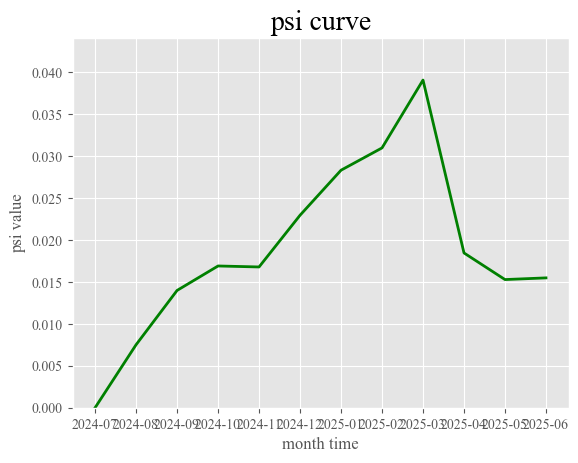

,moth,psi
0,2024-07,0.000000
1,2024-08,0.007508
2,2024-09,0.013981
3,2024-10,0.016898
4,2024-11,0.016781
5,2024-12,0.022945
6,2025-01,0.028316
7,2025-02,0.030973
8,2025-03,0.039062
9,2025-04,0.018451


In [43]:
from new_tools.new_psi import plot_month_psi_curve
plot_month_psi_curve(data_end, 'month_time')

In [44]:
import toad
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='train']['score'], data_end[data_end['target']=='train']['label'], 
                                   bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_train.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,336,562,0.064026,0.068405,0.138229,0.099335,1.391548,1.391548
1,563,574,0.056803,0.060224,0.224028,0.168832,1.234563,1.326927
2,575,582,0.049754,0.052359,0.529798,0.451594,1.081370,1.173174
3,583,598,0.047875,0.050282,0.681440,0.597329,1.040529,1.140811
4,599,619,0.042995,0.044926,0.776432,0.698984,0.934453,1.110800
5,620,639,0.039739,0.041383,0.861933,0.797980,0.863687,1.080144
6,640,661,0.034841,0.036099,0.937726,0.898071,0.757244,1.044156
7,662,898,0.028110,0.028923,1.000000,1.000000,0.610950,1.000000


In [48]:
from scipy.stats import kendalltau
kendalltau(score_ks['bad_rate'],score_ks.index,method='exact')

SignificanceResult(statistic=-0.9999999999999998, pvalue=4.96031746031746e-05)

In [47]:
tau,tau_p = kendalltau(score_ks['bad_rate'],score_ks.index)
tau,tau_p

(-0.9999999999999998, 4.96031746031746e-05)

In [49]:
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='valid']['score'], data_end[data_end['target']=='valid']['label'],
                                                                     bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_valid.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,336,562,0.065715,0.070337,0.141460,0.099040,1.428308,1.428308
1,563,574,0.054804,0.057981,0.225251,0.169385,1.191149,1.329817
2,575,582,0.049896,0.052516,0.531075,0.451384,1.084484,1.176547
3,583,598,0.047279,0.049625,0.681557,0.597824,1.027608,1.140063
4,599,619,0.043763,0.045766,0.778156,0.699381,0.951180,1.112636
5,620,639,0.038327,0.039854,0.860875,0.798680,0.833024,1.077872
6,640,661,0.033970,0.035164,0.934507,0.898408,0.738330,1.040181
7,662,875,0.029661,0.030567,1.000000,1.000000,0.644668,1.000000


In [50]:
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='oot']['score'], data_end[data_end['target']=='oot']['label'],
                               bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                              )
score_ks.to_csv(FILE_PATH + 'score_ks_oot.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,336,567,0.068561,0.073607,0.122201,0.094053,1.299281,1.299281
1,568,574,0.059799,0.063602,0.186594,0.150875,1.133238,1.236746
2,575,582,0.050741,0.053454,0.418996,0.392560,0.961590,1.067342
3,583,589,0.058181,0.061775,0.535197,0.497950,1.102583,1.074801
4,590,613,0.056813,0.060235,0.642470,0.597586,1.076651,1.075110
5,614,627,0.057440,0.060940,0.747549,0.694118,1.088535,1.076977
6,628,643,0.047107,0.049436,0.837992,0.795430,0.892721,1.053509
7,644,668,0.046035,0.048257,0.921850,0.891552,0.872405,1.033983
8,669,895,0.038026,0.039529,1.000000,1.000000,0.720625,1.000000


In [53]:
(4-(9*8/2-4))/(9*8/2)

-0.7777777777777778

In [57]:
from scipy.stats import kendalltau
kendalltau(score_ks['bad_rate'],score_ks.index)

SignificanceResult(statistic=-0.7777777777777778, pvalue=0.0024250440917107582)

In [58]:
from scipy.stats import kendalltau
kendalltau(score_ks['bad_rate'],-score_ks.index)

SignificanceResult(statistic=0.7777777777777778, pvalue=0.0024250440917107582)

In [55]:
tau,tau_p = kendalltau(score_ks['bad_rate'],score_ks.index)
tau,tau_p

(-0.7777777777777778, 0.0024250440917107582)

In [62]:
from scipy.stats import kendalltau
def kt_value(df,col ='bad_rate', reverse=True):
    if reverse:
        return kendalltau(df[col],-df.index)[0]
    else:
        return kendalltau(df[col],df.index)[0]
print(kt_value(score_ks))
print(kt_value(score_ks,reverse=False))

0.7777777777777778
-0.7777777777777778


#### 全样本统计

In [63]:
score_ks = se.show_statistic(data_end, bin_num=15, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 560.0, 568.0, 575.0, 583.0, 584.0, 600.0, 614.0, 626.0, 640.0, 650.0, 677.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,560.0,0.071560,12.974230,0.083250,0.054322,69410.0,0.030344,1.532509,1.000000,0.046695
1,560.0,568.0,0.057160,16.494845,0.151532,0.110104,71274.0,0.043458,1.376267,0.945678,0.045267
2,568.0,575.0,0.056087,16.829543,0.220066,0.167161,72905.0,0.055496,1.316487,0.889896,0.044521
3,575.0,583.0,0.049880,19.048188,0.517448,0.445555,355715.0,0.075414,1.161356,0.832839,0.043729
4,583.0,584.0,0.048950,19.429123,0.608608,0.532516,111114.0,0.079819,1.142892,0.554445,0.040640
5,584.0,600.0,0.048497,19.619849,0.677343,0.598697,84562.0,0.082499,1.131363,0.467484,0.039094
6,600.0,614.0,0.044631,21.406088,0.732401,0.656302,73604.0,0.079827,1.115953,0.401303,0.037544
7,614.0,626.0,0.043234,22.129938,0.802829,0.732367,97192.0,0.073914,1.096212,0.343698,0.036356
8,626.0,640.0,0.039707,24.184516,0.854787,0.793468,78072.0,0.064322,1.077279,0.267633,0.034401
9,640.0,650.0,0.036382,26.486190,0.896051,0.846430,67671.0,0.052052,1.058624,0.206532,0.032831


In [64]:
print(kt_value(score_ks))

0.9999999999999998


In [255]:
score_ks = se.show_statistic(data_end[data_end['target']=='oot'], bin_num=10, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 568.0, 575.0, 583.0, 590.0, 614.0, 628.0, 644.0, 669.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,568.0,0.068561,13.585629,0.122201,0.094053,12179.0,0.029716,1.299281,1.000000,0.052768
1,568.0,575.0,0.059799,15.722727,0.186594,0.150875,7358.0,0.037709,1.236746,0.905947,0.051129
2,575.0,583.0,0.050741,18.707809,0.418996,0.392560,31296.0,0.027909,1.067342,0.849125,0.050548
3,583.0,590.0,0.058181,16.187657,0.535197,0.497950,13647.0,0.039322,1.074801,0.607440,0.050472
4,590.0,614.0,0.056813,16.601637,0.642470,0.597586,12902.0,0.047385,1.075110,0.502050,0.048853
5,614.0,628.0,0.057440,16.409471,0.747549,0.694118,12500.0,0.056407,1.076977,0.402414,0.046882
6,628.0,644.0,0.047107,20.228155,0.837992,0.795430,13119.0,0.044933,1.053509,0.305882,0.043551
7,644.0,669.0,0.046035,20.722513,0.921850,0.891552,12447.0,0.031985,1.033983,0.204570,0.041789
8,669.0,inf,0.038026,25.297753,1.000000,1.000000,14043.0,0.000000,1.000000,0.108448,0.038026


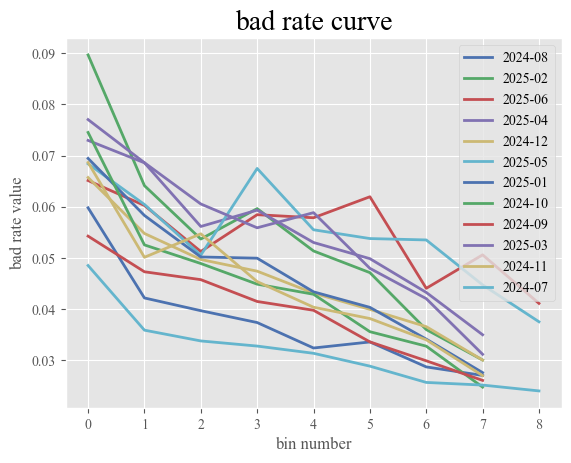

In [256]:
plt.style.use('seaborn-deep')
plt.rcParams['font.sans-serif'] = 'Times New Roman'
se.plot_badrate(data_end, bin_num=10, col_name='month_time')

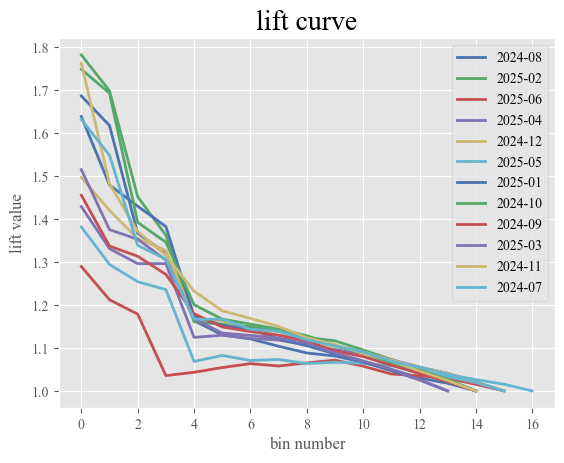

In [257]:
se.plot_lift(data_end, bin_num=20, col_name='month_time')

In [258]:
SAVE_PATH = FILE_PATH + '上线文档/'
isExists = os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

#### 原始文件

In [259]:
# data_org = pd.read_pickle(DATA_PATH + 'data_model.pickle')
data_org = pd.read_parquet(DATA_PATH + 'data_model.parquet')
# data_con = pd.read_pickle(DATA_PATH + 'data_con.pkl')
# data_con['backPointTime'] = pd.to_datetime(data_con['backPointTime'])
# data_org['backPointTime'] = pd.to_datetime(data_org['backPointTime'])
# data_org = pd.merge(data_org, data_con, on=['applist_json','mobile', 'backPointTime'])

In [260]:
data_org

,mobile,backPointTime,qudao3_act,label,TZ_1381_m12,TZ_1381_m24,TZ_1381_m18,TZ_0264_m15,TZ_0264_m12,TZ_0264_m18,...,TZ_0443_m8,TZ_0455_m3,TZ_0418_m11,TZ_0269_w4,TZ_0049_m12,target,month_time,day_time,week_time,weight
0,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,8.0,-1.0,0.0,0.0,valid,2024-08,2024-08-11,32,1
1,663c8e4d4a0d11fa9767b332f30c1921,2024-08-11,信息流,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,8.0,-1.0,0.0,0.0,train,2024-08,2024-08-11,32,1
2,f3f4e2f3c61d8f1a035a0c32987714a5,2025-02-21,API,0.0,-1.0,10.0,-1.0,1.0,1.0,1.0,...,-1.0,0.0,-1.0,-1.0,0.0,valid,2025-02,2025-02-21,8,1
3,6d09e74a845b0c12e86be848d40f4fd3,2025-06-09,API,0.0,20.0,20.0,20.0,35.0,35.0,35.0,...,-1.0,3.0,1.0,0.0,0.0,oot,2025-06,2025-06-09,24,1
4,70a24bd8e0cfa4efb16a5a26b3054bc5,2025-04-28,API,0.0,18.0,20.0,20.0,20.0,18.0,20.0,...,-1.0,-1.0,1.0,2.0,0.0,train,2025-04,2025-04-28,18,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277737,a18e8ccd88bb61bc7f9dd825d25b8850,2024-11-13,APP自然流量,0.0,24.0,31.0,30.0,27.0,25.0,31.0,...,0.0,-1.0,1.0,2.0,0.0,train,2024-11,2024-11-13,46,1
1277738,e0c1b14d5f5953670ed63c102f3ead9f,2024-11-15,APP自然流量,0.0,-1.0,-1.0,-1.0,20.0,20.0,20.0,...,1.0,-1.0,1.0,-1.0,1.0,train,2024-11,2024-11-15,46,1
1277739,82bc32734d6acd2f8993add147648f26,2024-11-12,APP自然流量,0.0,25.0,38.0,25.0,26.0,26.0,26.0,...,1.0,0.0,1.0,-1.0,1.0,train,2024-11,2024-11-12,46,1
1277740,45ed4aab69e0a3039def1ed484e79716,2024-11-23,APP自然流量,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,0.0,valid,2024-11,2024-11-23,47,1


In [261]:
data_org['weight'] = 1
data_org = data_org[keep_lst + ['backPointTime']]
data_org['backPointTime'] = pd.to_datetime(data_org['backPointTime'])

In [262]:

data_org

,TZ_0265_m15,TZ_0265_m18,TZ_0000_m24,TZ_0404_m10,TZ_0402_m10,TZ_0402_m11,TZ_0099_m3,TZ_0097_m3,TZ_0096_m3,TZ_0245_m4,TZ_0099_m6,TZ_1574_m12,TZ_0277_m24,TZ_0265_m6,TZ_0265_m12,TZ_0276_m15,TZ_0279_m24,backPointTime
0,0.0,0.0,2.0,0.000000,1.0,1.0,0.0,0.0,0.0,8.0,0.0,-1.0,-1.0,0.0,0.0,-1.0,0.0000,2024-08-11
1,0.0,0.0,2.0,0.000000,1.0,1.0,0.0,0.0,0.0,8.0,0.0,-1.0,-1.0,0.0,0.0,-1.0,0.0000,2024-08-11
2,0.0,0.0,8.0,1.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,-1.0,0.0000,2025-02-21
3,5.0,5.0,3.0,0.000000,1.0,1.0,0.0,0.0,0.0,2.0,0.0,-1.0,12.0,6.0,5.0,26.0,832373.4375,2025-06-09
4,1.0,1.0,2.0,0.000000,1.0,1.0,0.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,2.0,1.0,-1.0,0.0000,2025-04-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1277737,4.0,4.0,2.0,0.333333,1.0,1.0,0.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,2.0,3.0,-1.0,0.0000,2024-11-13
1277738,3.0,3.0,0.0,0.000000,1.0,1.0,0.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,3.0,3.0,-1.0,0.0000,2024-11-15
1277739,5.0,5.0,1.0,0.250000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,18.0,4.0,5.0,23.0,0.0000,2024-11-12
1277740,-1.0,-1.0,0.0,-1.000000,-1.0,-1.0,0.0,0.0,0.0,20.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0000,2024-11-23


In [263]:
data_org.to_csv(SAVE_PATH + '原始文档.csv', index=False, encoding='utf-8-sig')

#### 对照文件

In [264]:
data_comp = data_end[data_end['target'].isin(['valid', 'train'])].iloc[:1000, :]
data_comp.to_csv(SAVE_PATH + '对照文档.csv', index=False, encoding='utf-8-sig')
data_comp

,TZ_0265_m15,TZ_0282_m24,TZ_0089_m24,TZ_0280_m24,TZ_0091_m24,TZ_0088_m24,TZ_0281_m18,TZ_0265_m18,TZ_0282_m18,TZ_0280_m15,...,qudao3_act,label,weight,target,month_time,day_time,week_time,proba,score,bucket
0,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,信息流,0.0,1,train,2024-08,2024-08-11,32,0.622792,583,4
1,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,信息流,0.0,1,valid,2024-08,2024-08-11,32,0.622792,583,4
2,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,valid,2025-02,2025-02-21,8,0.625168,581,3
4,1.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,1.0,-1.0,-1.0,...,API,0.0,1,valid,2025-04,2025-04-28,18,0.576269,622,7
5,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,train,2024-12,2024-12-24,52,0.622792,583,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,2.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,2.0,-1.0,-1.0,...,API,0.0,1,train,2024-10,2024-10-25,43,0.583778,616,7
1098,5.0,20.0,1.0,20.0,0.041667,1.0,-1.0,7.0,-1.0,-1.0,...,API,0.0,1,valid,2025-02,2025-02-10,7,0.509317,677,11
1099,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,train,2025-03,2025-03-02,9,0.622792,583,4
1100,0.0,-1.0,0.0,-1.0,0.000000,0.0,-1.0,0.0,-1.0,-1.0,...,API,0.0,1,valid,2024-12,2024-12-11,50,0.606983,597,5


In [265]:
import joblib
model = joblib.load('model.model')

In [266]:
# keep_lst = pd.read_csv('keep_lst.csv')['var_names'].tolist()
# len(keep_lst)

#### 模型pmml文件

In [267]:
from sklearn2pmml import sklearn2pmml, PMMLPipeline
from sklearn.pipeline import make_pipeline

flag = 1

if flag:
    train = data_end[data_end['target']=='train']

    pipeline = PMMLPipeline([("classifier", model)])
    pipeline.fit(train[keep_lst], train['label'])
    sklearn2pmml(pipeline, SAVE_PATH + 'model.pmml', with_repr=True)
else:
    model.save_model( SAVE_PATH + 'model')

In [268]:
import joblib
joblib.dump(model, SAVE_PATH + 'model.model')

['/home/zhuchen/poc/02-xyf2/deltaV1_all/file/上线文档/model.model']

In [269]:
model.save_model(SAVE_PATH +'model.json')

#### 入模变量

In [270]:
pd.DataFrame({'var_names': keep_lst}).to_csv(SAVE_PATH + 'keep_lst.csv')

### 报告输出

In [271]:
SAVE_PATH = FILE_PATH + '建模报告/'
isExists=os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

In [ ]:
if_single_ks = False
if_single_lift = False
if_weight = True


# 新增自动报告输出  但是这里还需要改
# 计算train和oot的psi值
from new_tools import new_psi,feature_plot_generator
keep_list = keep_lst

psi_df_tv_o = new_psi.psi_for_continue_var(data_end[data_end['target'].isin(['train','valid'])]['proba'],
                                        data_end[data_end['target'].isin(['oot'])]['proba'],
                                        detail=True,method='equal_width')
psi_df_tv_o

min_month = data_end['month_time'].min()

psi_df_month = new_psi.choice_month_psi(data_end,min_month,'proba','month_time')
psi_df_month


df_list = []
temp_df = pd.DataFrame({
    'dataset':'all',
    'count':data_end['label'].count(),
    'badrate':data_end['label'].mean(),
    'badrate_weight':(data_end['label']*data_end['weight']).sum()/data_end['weight'].sum(),
    'month_min':data_end['month_time'].min(),
    'month_max':data_end['month_time'].max()
},index=[0])
df_list.append(temp_df)

def group_weight_badrate_cal(group):
    return (group['label']*group['weight']).sum()/group['weight'].sum()

for col in ['target','month_time']:
    temp_df = data_end.groupby(col).agg({'label':['count','mean'],'month_time':['min','max']}).reset_index()
    temp_df.columns = ['dataset','count','badrate','month_min','month_max']
    temp_df['badrate_weight'] = (
        data_end.groupby(col)
        .apply(group_weight_badrate_cal)  # 使用apply接收完整分组
        .reset_index(drop=True)
    )
    temp_df.sort_values(by='dataset',ascending=True,inplace=True)
    df_list.append(temp_df)
info_df = pd.concat(df_list,axis=0,ignore_index=True)

if not if_weight:
    info_df.drop(columns = ['badrate_weight'],axis=0,inplace=True)

info_df

import toad
tag_list = [['train'],['valid'],['oot']]
tag_list_str = [str(i) for i in tag_list]
df_list = []

for tag in tag_list:
    temp_df = data_end[data_end['target'].isin(tag)]
    score_ks =  toad.metrics.KS_bucket(temp_df['proba'],
                                        temp_df['label'], 
                                        bucket=10,
                                        )
    lift_df_diff = score_ks[['min','max','lift','cum_lift']]
    df_list.append(lift_df_diff)

lift_df = pd.concat(df_list,axis=1,keys=tag_list_str)
lift_df

from new_tools import iv_report

iv_calculator = iv_report.IVCalculator(data_end,label='label',target='target',keep_list=keep_list, max_leaf_nodes=6, min_samples_leaf=0.05)
iv_df = iv_calculator.iv_report(use_thread=True,max_workers=20)
iv_df.sort_values(by='train_iv',ascending=False,inplace=True)
iv_df.to_excel(SAVE_PATH + 'iv_report.xlsx',index=False)
ipt_df = pd.DataFrame({'var_name': keep_list, 'importance': model.feature_importances_})
ipt_df.sort_values(by='importance', ascending=False, inplace=True)
ipt_iv_df = pd.merge(ipt_df,iv_df,on='var_name',how='left')
ipt_iv_df.to_excel(SAVE_PATH+'ipt_iv.xlsx',index=False)

iv_detail_df = iv_calculator.detail_report(ipt_iv_df['var_name'],'all')


if if_single_ks:
    # 基于配置参数，来决定是否进行输出
    ipt_iv_df = pd.merge(ipt_iv_df,iv_detail_df[['var_name','ks']].drop_duplicates(subset=['var_name']),on='var_name',how='left')
    ipt_iv_df['ks'] = ipt_iv_df['ks'].fillna(0)
iv_detail_df.drop(columns=['ks','badCumRate','goodCumRate'],inplace=True)

if if_single_lift:
    # 基于配置参数，来决定是否进行输出
    def calc_lift(df):
        total_bad = df['bad'].sum()
        total_cnt = df['total'].sum()
        overall_bad_rate = total_bad / total_cnt
        df['lift'] = df['bad_rate'] / overall_bad_rate
        
        return df

    iv_detail_df = iv_detail_df.groupby('var_name', group_keys=False).apply(calc_lift)


import re

def extract_left(bin_str):
    """从区间字符串中提取左端点数值"""
    try:
        left = re.findall(r'[\[\(](-inf|-?\d+\.?\d*)', str(bin_str))[0]
        return float('-inf') if left == '-inf' else float(left)
    except IndexError:
        return float('inf')  # 异常值放最后

iv_detail_df = iv_detail_df.sort_values(
    by=['var_name', 'bin'],
    key=lambda s: s if s.name == 'var_name' else s.map(extract_left),
    ascending=[True, True]  # var_name升序，bin升序
)


model_performance_ks = pd.concat([res_data[['datasets','auc','ks']], res_month[['datasets','auc','ks']]])
def calc_lift(group):
    high_thr = group['score'].quantile(0.95)
    low_thr = group['score'].quantile(0.05)
    top5 = group[group['score'] >= high_thr]
    bottom5 = group[group['score'] <= low_thr]
    bad_rate_all = (group['label'] == 1).mean()
    bad_rate_top5 = (top5['label'] == 1).mean()
    bad_rate_bottom5 = (bottom5['label'] == 1).mean()
    lift_top5 = bad_rate_top5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    lift_bottom5 = bad_rate_bottom5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    return pd.Series({'sub_5_lift': lift_top5,'top_5_lift': lift_bottom5})

result_data = data_end.groupby('target').apply(calc_lift).reset_index()
result_month = data_end.groupby('month_time').apply(calc_lift).reset_index()
result_data.rename(columns={'target':'datasets'},inplace=True)
result_month.rename(columns={'month_time':'datasets'},inplace=True)
model_performance_lift = pd.concat([result_data,result_month])
eval_df = pd.merge(model_performance_ks,model_performance_lift,on='datasets',how='left')


with pd.ExcelWriter(SAVE_PATH + '模型评估报告.xlsx') as writer:
    info_df.to_excel(writer, sheet_name='数据概要', index=False)
    eval_df.to_excel(writer, sheet_name='模型性能', index=True)
    ipt_iv_df.to_excel(writer, sheet_name='特征重要性', index=False)
    iv_detail_df.to_excel(writer, sheet_name='特征分箱', index=False)
    lift_df.to_excel(writer, sheet_name='lift', index=True)
    psi_df_tv_o.to_excel(writer, sheet_name='psi_训练与oot', index=False)
    psi_df_month.to_excel(writer, sheet_name='psi_逐月', index=False)
    pdo_df.to_excel(writer, sheet_name='打分参数', index=False)
    feature_plot_generator.create_feature_plot_report(
        excel_writer=writer,
        data=data_end,
        feature_list=keep_lst,
        sheet_name='特征分箱报告'
    )

初始化IV计算器,获取各个数据集的索引...
初始化完成


计算在所有数据集上的IV分箱细节: 100%|██████████| 17/17 [00:01<00:00, 16.76it/s]


#### 特征重要性+iv+psi+分箱细节

In [273]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
key_value = pd.read_excel(FILE_PATH + 'key_value.xlsx')
key_value = key_value[key_value['var_names'].isin(keep_lst)]
result = pd.merge(feature_importance, key_value, on='var_names')
result.to_csv(SAVE_PATH + 'ipt_iv_psi.csv', index=False, encoding='utf-8-sig')

In [274]:
result

,var_names,importance,Unnamed: 0.1,Unnamed: 0,ks,iv_bin_train,iv_bin_valid,iv_bin_oot,iv_bin_total,psi_tv_bin,...,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,max
0,TZ_0265_m15,0.314584,209,209,0.000000,0.029660,0.030082,0.022132,0.025864,8.897142e-06,...,-1.0,0.000000,0.0,1.0,1.00,2.0,5.000000,9.000000,2.300000e+01,5.600000e+01
1,TZ_0277_m24,0.146562,134,134,0.000000,0.015435,0.019124,0.010305,0.015079,1.119278e-06,...,-1.0,-1.000000,-1.0,-1.0,-1.00,-1.0,10.000000,13.000000,1.700000e+01,2.000000e+01
2,TZ_0265_m12,0.090240,221,221,0.000000,0.028997,0.029368,0.020026,0.025206,1.594937e-06,...,-1.0,0.000000,0.0,1.0,1.00,2.0,5.000000,8.000000,2.000000e+01,5.600000e+01
3,TZ_0099_m6,0.087337,8,8,0.016829,0.005494,0.002781,0.003666,0.004411,8.548416e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.166667,0.666667,2.700000e+00,2.213767e+03
4,TZ_0096_m3,0.053729,1,1,0.020140,0.004421,0.004264,0.004259,0.004297,7.867307e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.000000,1.000000,4.000000e+00,1.240000e+02
5,TZ_0279_m24,0.047617,245,245,0.000000,0.009736,0.012197,0.008738,0.010030,7.197039e-06,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.000000,4329.802734,2.403400e+06,1.245205e+07
6,TZ_1574_m12,0.045761,191,191,0.000000,0.006614,0.006057,0.006477,0.006292,9.907937e-06,...,-1.0,-1.000000,-1.0,-1.0,-1.00,-1.0,-1.000000,2.000000,2.000000e+01,4.700000e+01
7,TZ_0099_m3,0.033613,2,2,0.020029,0.004362,0.004244,0.004563,0.004290,3.681340e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.000000,0.333333,2.333333e+00,1.400333e+03
8,TZ_0097_m3,0.028570,0,0,0.020140,0.004421,0.004264,0.004259,0.004297,7.867307e-07,...,0.0,0.000000,0.0,0.0,0.00,0.0,0.000000,1.000000,3.000000e+00,7.100000e+01
9,TZ_0265_m6,0.027498,187,187,0.000000,0.026053,0.026000,0.018357,0.022084,1.615716e-05,...,-1.0,-1.000000,0.0,0.0,1.00,2.0,4.000000,7.000000,2.000000e+01,5.600000e+01


In [275]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
feature_importance = feature_importance[feature_importance['var_names'].isin(end_keep)]
key_value = pd.read_excel(FILE_PATH + 'bins_detail.xlsx')
key_value = key_value[key_value['variable'].isin(end_keep)]
result = pd.merge(feature_importance, key_value, left_on='var_names',right_on='variable')
result.to_csv(SAVE_PATH + 'bin_details.csv', index=False, encoding='utf-8-sig')

In [276]:
%reset -f